In [70]:
import numpy as np
import pandas as pd

def aggregate_de_results(
    df,
    group_col="symbol",
    strata_col="level_0",
    lfc_col="log2FoldChange",
    se_col="lfcSE",
    basemean_col="baseMean",
):
    """
    Aggregate DE results across strata (e.g. level_0) for each gene/symbol
    using empirical Bayes-style inverse-variance weighting.

    Returns:
        DataFrame with:
            symbol
            log2FoldChange   # EB pooled estimate
            lfcSE            # pooled SE
            baseMean         # mean baseMean across strata
            n_strata
    """

    def _aggregate_group(g):
        # remove invalid rows
        g = g[
            np.isfinite(g[lfc_col]) &
            np.isfinite(g[se_col]) &
            (g[se_col] > 0)
        ].copy()

        if len(g) == 0:
            return pd.Series({
                "log2FoldChange": np.nan,
                "lfcSE": np.nan,
                "baseMean": np.nan,
                "n_strata": 0,
            })

        # observed effects + variances
        y = g[lfc_col].values
        v = g[se_col].values ** 2

        # ---- empirical Bayes random-effects shrinkage ----
        # DerSimonian-Laird estimate for between-study variance tau^2

        w_fixed = 1 / v
        mu_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

        Q = np.sum(w_fixed * (y - mu_fixed) ** 2)
        df_Q = len(y) - 1

        C = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))

        tau2 = max(0, (Q - df_Q) / C) if C > 0 else 0

        # EB/random-effects weights
        w = 1 / (v + tau2)

        mu = np.sum(w * y) / np.sum(w)

        # pooled standard error
        se = np.sqrt(1 / np.sum(w))

        return pd.Series({
            "log2FoldChange": mu,
            "lfcSE": se,
            "baseMean": g[basemean_col].mean(),
            "n_strata": len(g),
        })

    out = (
        df.groupby(group_col, observed=True)
        .apply(_aggregate_group)
        .reset_index()
    )

    return out

In [95]:
import pathlib
import pandas as pd

df = pd.concat({
    f.stem: pd.read_csv(f, index_col=0).drop_duplicates(subset=["symbol"]).set_index("symbol")
    for f in pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/cell-deconvolution/output/microglial cell/").glob("*.csv")
}).reset_index()

In [96]:
df = aggregate_de_results(df).set_index("symbol")

In [3]:
from tqdm import tqdm
import meta_analysis
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn, IterativeProportionalFitting
from meta_analysis.meta import MetaAnalysis

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import importlib
importlib.reload(meta_analysis)

<module 'meta_analysis' from '/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/__init__.py'>

In [77]:
GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    # "GO_MF": "GO_Molecular_Function_2025",
    # "GO_CC": "GO_Cellular_Component_2025",
    # "Reactome": "Reactome_Pathways_2024",
    # "SynGO": "SynGO_2024",
    # "WikiPathways": "WikiPathways_2024_Human",
    # "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    # "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

100%|██████████| 1/1 [00:03<00:00,  3.21s/it]


In [97]:
genes_available = df.index.intersection(GO_TERMS["GO_BP"].index)
go_terms_available = GO_TERMS["GO_BP"].columns[GO_TERMS["GO_BP"].loc[genes_available].sum(axis=0).gt(0)]

df = df.loc[genes_available]
balanced_matrix = UnbalancedSinkhorn() \
    .get_balanced_matrix(
        GO_TERMS["GO_BP"].loc[genes_available, go_terms_available],
        tolerance=1e-12
    )

Unbalanced Sinkhorn:   2%|▏         | 22/1000 [00:02<01:52,  8.67it/s]


In [98]:
import numpy as np

table = pd.DataFrame(
    MetaAnalysis().generate_meta_estimate(
        df.loc[genes_available], 
        balanced_matrix.loc[genes_available, go_terms_available]
    )
)

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/meta.py:76: RuntimeWarning: divide by zero encountered in log10
  "log10p_eb": -np.log10(norm.sf(np.abs(shrunken_estimate / shrunken_standard_error)) * 2),


<Axes: xlabel='naive_estimate', ylabel='shrunken_estimate'>

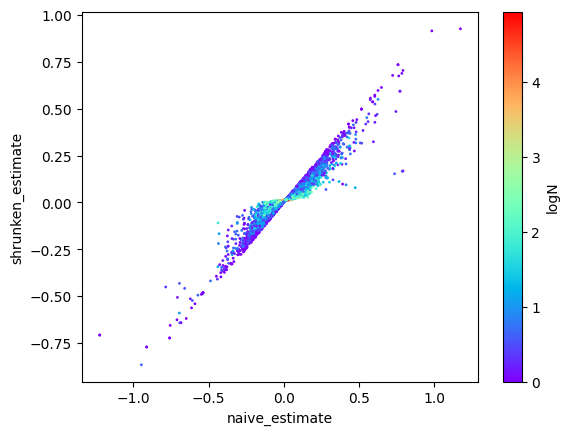

In [99]:
table.eval("logN = log(n_eff)") \
    .plot.scatter(x="naive_estimate", y="shrunken_estimate", c="logN", cmap="rainbow", s=1)

<Axes: xlabel='n_eff', ylabel='shrunken_estimate'>

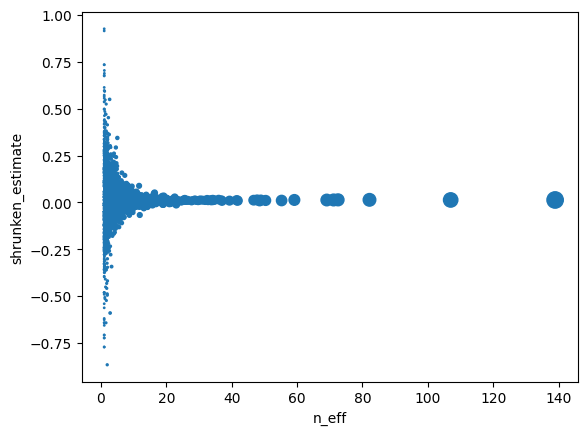

In [100]:
table.eval("logweights = log(weights)").plot.scatter(x="n_eff", y="shrunken_estimate", s="n_eff")

<Axes: xlabel='shrunken_estimate', ylabel='log10p_eb'>

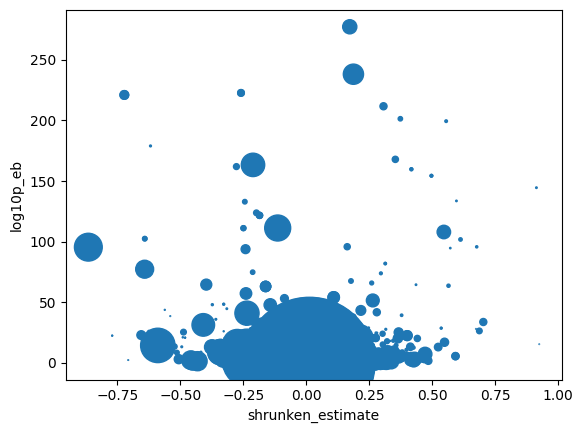

In [112]:
table.eval("n_eff = n_eff * 10").plot.scatter(x="shrunken_estimate", y="log10p_eb", s="weights")

In [111]:
table.query("p_eb < 0.05 and n_eff > 1").sort_values(by="p_eb")

,weights,n_eff,naive_estimate,naive_standard_error,shrunken_estimate,shrunken_se,z_naive,z_eb,p_naive,p_eb,log10p_naive,log10p_eb,B,full_dataset_mean,full_dataset_standard_error
Detection of Molecule of Bacterial Origin (GO:0032490),94.319263,1.320932,0.575483,0.109057,0.546662,0.024685,5.276906,22.145276,1.313831e-07,1.158504e-108,6.881461,107.936103,0.948765,0.012948,0.22024
Humoral Immune Response Mediated by Circulating Immunoglobulin (GO:0002455),400.815674,1.918225,-0.946465,0.142820,-0.865141,0.041581,-6.626979,-20.806122,3.426266e-11,3.809402e-96,10.465179,95.419143,0.915236,0.012948,0.22024
Negative Regulation of Macrophage Differentiation (GO:0045650),166.752397,1.556113,-0.691099,0.129253,-0.641459,0.034321,-5.346870,-18.690172,8.948839e-08,5.952083e-78,7.048233,77.225331,0.929493,0.012948,0.22024
B Cell Chemotaxis (GO:0035754),85.599384,1.999887,0.273942,0.091204,0.264443,0.017399,3.003610,15.198522,2.667975e-03,3.616923e-52,2.573818,51.441661,0.963606,0.012948,0.22024
Negative Regulation of Peroxisome Proliferator Activated Receptor Signaling Pathway (GO:0035359),49.050841,1.444300,0.224073,0.086333,0.217162,0.015620,2.595445,13.902863,9.446839e-03,6.085770e-44,2.024713,43.215684,0.967266,0.012948,0.22024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Negative Regulation of Nucleobase-Containing Compound Metabolic Process (GO:0045934),38.201758,1.843046,-0.064261,0.120916,-0.059454,0.030169,-0.531451,-1.970720,5.951060e-01,4.875592e-02,0.225406,1.311973,0.937748,0.012948,0.22024
Aorta Development (GO:0035904),43.190085,2.192009,0.249413,0.232308,0.202874,0.103060,1.073633,1.968515,2.829874e-01,4.900879e-02,0.548233,1.309726,0.803189,0.012948,0.22024
Negative Regulation of Granulocyte Differentiation (GO:0030853),189.164265,1.752673,-0.693237,0.360283,-0.431369,0.219394,-1.924149,-1.966183,5.433597e-02,4.927747e-02,1.264913,1.307352,0.629179,0.012948,0.22024
Adaptive Imm Resp Based on Som Recomb of Imm Rcptrs Built Frm IgSF Domains (GO:0002460),121.557984,2.053330,0.479771,0.311028,0.337302,0.171824,1.542533,1.963067,1.229441e-01,4.963838e-02,0.910292,1.304182,0.694812,0.012948,0.22024


/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/pl.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


(          gene      L2FC        SE  lower_ci  upper_ci  pct_contribution
 MSH2      MSH2 -0.344529  0.124456 -0.588463 -0.100595          0.009485
 IL18BP  IL18BP  0.060864  0.165124 -0.262779  0.384508          0.013726
 PHB1      PHB1 -0.221213  0.096853 -0.411045 -0.031382          0.019742
 GNL1      GNL1  0.193225  0.082990  0.030563  0.355886          0.028787
 STAT3    STAT3 -0.143590  0.088539 -0.317126  0.029946          0.048410
 CD46      CD46  0.132399  0.062809  0.009294  0.255505          0.111281
 CD8A      CD8A  0.459543  0.138392  0.188295  0.730791          0.119253
 TLR4      TLR4  0.658947  0.082333  0.497574  0.820320          0.649318,
 <Figure size 1100x506 with 4 Axes>,
 array([[<Axes: xlabel='log2 fold change'>, <Axes: xlabel='Contribution'>],
        [<Axes: xlabel='meta log2 fold change'>, <Axes: >]], dtype=object))

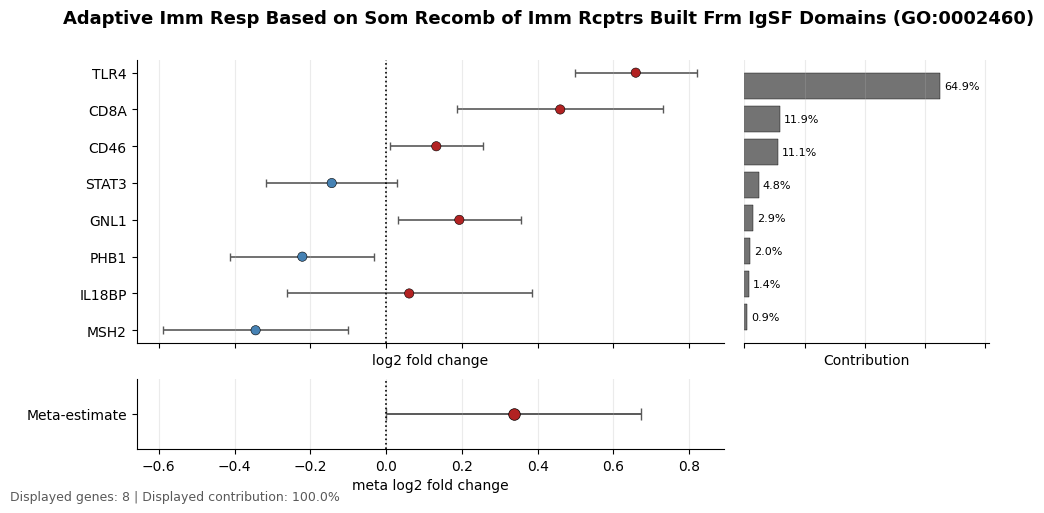

In [110]:
from meta_analysis.pl import ForestPlotter

###### SOMETHING HORRIBLE IS GOING ON HERE
ForestPlotter(df, (balanced_matrix.T * df["baseMean"]).T, table) \
    .plot_term("Adaptive Imm Resp Based on Som Recomb of Imm Rcptrs Built Frm IgSF Domains (GO:0002460)", cutoff=1)